# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

# Load Dataset

In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data,
     data.target.rename("HousePrice")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Dataset Information

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

Dataset Shape: (20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


# Define Features and Target

In [4]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


# Feature Scaling

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


# Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 16512
Testing Samples: 4128


# Linear Regression

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R²:", lr_r2)

Linear Regression RMSE: 0.7455813830127763
Linear Regression R²: 0.5757877060324508


# Ridge Regression

In [8]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression RMSE: 0.7455542909384609
Ridge Regression R²: 0.5758185345441322


# Decision Tree (Baseline)

In [9]:
tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

print("Train RMSE:", train_rmse)
print("Test RMSE :", test_rmse)

Train RMSE: 3.0176010694886063e-16
Test RMSE : 0.7021725586639983


# Overfitting Check

In [10]:
if train_rmse < (test_rmse * 0.5):
    print("Possible Overfitting Detected")
else:
    print("No Major Overfitting")

Possible Overfitting Detected


# Cross Validation

In [11]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores.mean()

print("Cross Validation RMSE:", cv_rmse)

Cross Validation RMSE: 0.8961572070066897


# Hyperparameter Tuning

In [12]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 10}


# Best Model

In [13]:
best_tree = grid.best_estimator_

best_tree.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

# Evaluate Tuned Decision Tree

In [14]:
y_pred = best_tree.predict(
    X_test
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

tree_r2 = r2_score(
    y_test,
    y_pred
)

print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R²:", tree_r2)

Decision Tree RMSE: 0.6454300828015771
Decision Tree R²: 0.6820992539714815


# Model Comparison Table

In [15]:
results = {
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Tuned Decision Tree"
    ],
    "RMSE": [
        lr_rmse,
        ridge_rmse,
        tree_rmse
    ],
    "R2 Score": [
        lr_r2,
        ridge_r2,
        tree_r2
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


# Best Model Selection

In [16]:
best_model = comparison_df.loc[
    comparison_df["R2 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model       Tuned Decision Tree
RMSE                    0.64543
R2 Score               0.682099
Name: 2, dtype: object


# RMSE Comparison Graph

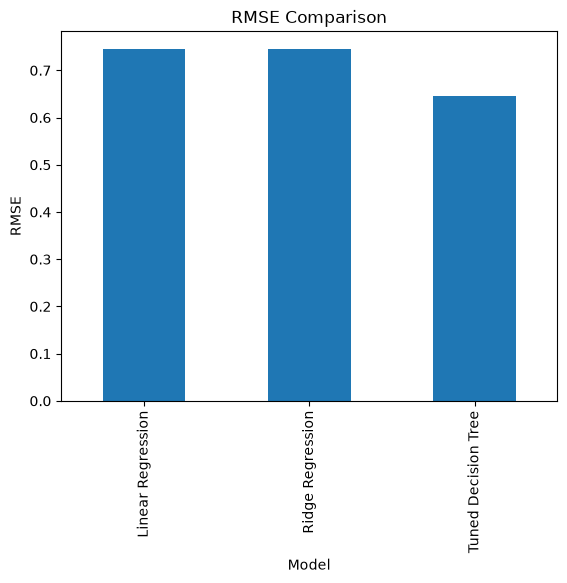

In [17]:
comparison_df.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    legend=False
)

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

# R² Comparison Graph

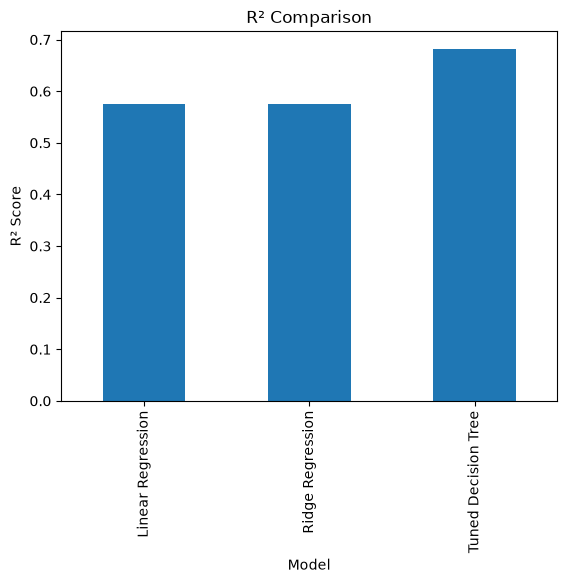

In [18]:
comparison_df.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    legend=False
)

plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.show()

# CONCLUSION

In [19]:
print("""
Conclusion

1. Linear Regression model was trained and evaluated.
2. Ridge Regression model was trained and evaluated.
3. Decision Tree model showed signs of overfitting.
4. Cross Validation was performed.
5. GridSearchCV was used for hyperparameter tuning.
6. RMSE and R² were used as evaluation metrics.
7. Models were compared and the best model was selected.
""")


Conclusion

1. Linear Regression model was trained and evaluated.
2. Ridge Regression model was trained and evaluated.
3. Decision Tree model showed signs of overfitting.
4. Cross Validation was performed.
5. GridSearchCV was used for hyperparameter tuning.
6. RMSE and R² were used as evaluation metrics.
7. Models were compared and the best model was selected.



# Saved trained model using joblib

In [21]:
joblib.dump(
    best_tree,
    "best_decision_tree_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
